<a href="https://colab.research.google.com/github/HoFangHuy/AI/blob/main/BTVN_CNN_HoangHuy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import zipfile

uploaded = files.upload()

# Giải nén thư mục
for filename in uploaded.keys():
    if filename.endswith(".zip"):
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall("/content/hhhhh_data")

Saving Ảnh training.zip to Ảnh training.zip


In [ ]:
zip_path = "/content/Ảnh training.zip"
extract_path = "/content/hhhhhdeptrai_data"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [ ]:
import os
import numpy as np
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

student_info = {
    'person1': {'name': 'Chi Kien', 'MSSV': '3124102xxxx'},
    'person2': {'name': 'Hoang Huy', 'MSSV': '31241022417'},
    'person3': {'name': 'Ngoc Hao', 'MSSV': '3124102xxxx'},
    'person4': {'name': 'Quang Truong', 'MSSV': '31241023392'},
    'person5': {'name': 'Xuan Loc', 'MSSV': '3124102xxxx'},
}

# Load ảnh từ thư mục
data = []
labels = []

base_dir = '/content/hhhhhdeptrai_data/Ảnh training'

for person in os.listdir(base_dir):
    person_path = os.path.join(base_dir, person)
    if os.path.isdir(person_path):
        for emotion in os.listdir(person_path):
            emotion_path = os.path.join(person_path, emotion)
            for img_file in os.listdir(emotion_path):
                img_path = os.path.join(emotion_path, img_file)
                img = cv2.imread(img_path)
                img = cv2.resize(img, (64, 64))  #đặt lại khung ảnh
                data.append(img)
                labels.append((person, emotion))

# chuẩn hóa
X = np.array(data, dtype="float32") / 255.0
y_raw = ['{}_{}'.format(p, e) for p, e in labels]

#gắn nhãn
le = LabelEncoder()
y = le.fit_transform(y_raw)
y = to_categorical(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(len(y[0]), activation='softmax')  #đầu ra bằng số nhãn dc gán
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test))


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 564ms/step - accuracy: 0.1091 - loss: 2.2411 - val_accuracy: 0.3725 - val_loss: 2.0735
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 397ms/step - accuracy: 0.1984 - loss: 2.0641 - val_accuracy: 0.3333 - val_loss: 1.9803
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 406ms/step - accuracy: 0.1869 - loss: 2.0274 - val_accuracy: 0.3333 - val_loss: 1.9066
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 472ms/step - accuracy: 0.2114 - loss: 1.9991 - val_accuracy: 0.3333 - val_loss: 1.7997
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 406ms/step - accuracy: 0.2604 - loss: 1.8666 - val_accuracy: 0.4118 - val_loss: 1.5396
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 573ms/step - accuracy: 0.3004 - loss: 1.7537 - val_accuracy: 0.4118 - val_loss: 1.4315
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 395ms/step - accuracy: 0.3284 - loss: 1.6061 - val_accuracy: 0.4510 - val_loss: 1.3564
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 395ms/step - accuracy: 0.3598 - loss: 1.6565 - val_accuracy: 0.5294 - val_loss:

In [ ]:
model.save('cnn_face_model3.h5')

In [ ]:
import pickle
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

In [1]:
import cv2
import numpy as np
import pickle
from tensorflow.keras.models import load_model

model = load_model('cnn_face_model3.h5')
with open('label_encoder2.pkl', 'rb') as f:
    le = pickle.load(f)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.preprocessing import image


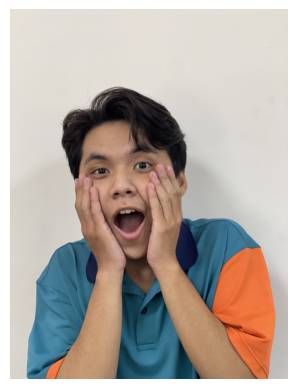

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Quang Truong đang cảm thấy WOW


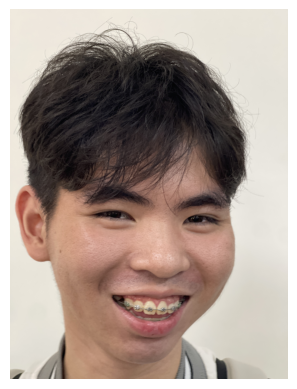

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Xuan Loc đang cảm thấy HAPPY


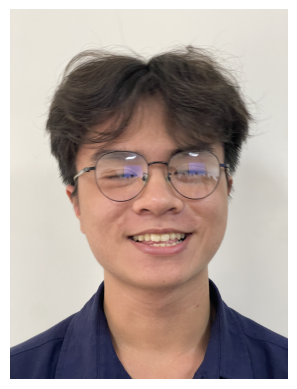

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Ngoc Hao đang cảm thấy HAPPY


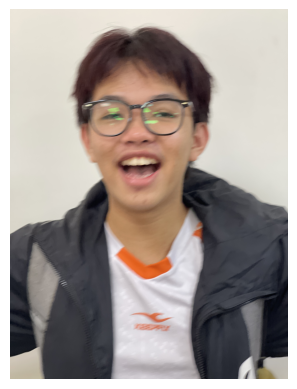

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Chi Kien đang cảm thấy HAPPY


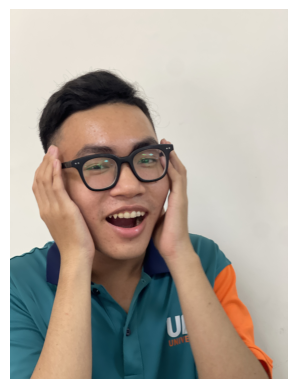

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Hoang Huy đang cảm thấy WOW


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import load_model
import pickle
from PIL import Image, ImageOps

def predict_image(img_path):
    img_display = Image.open(img_path)
    img_display = ImageOps.exif_transpose(img_display)
    plt.imshow(img_display)
    plt.axis('off')
    plt.show()

    img = img_display.resize((64, 64))
    img = img_to_array(img) / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)
    class_index = np.argmax(pred)
    confidence = np.max(pred)
    label = le.inverse_transform([class_index])[0]

    try:
        name, emotion = label.split('_')
    except:
        name, emotion = "Unknown", "Unknown"

    print(f"{name} đang cảm thấy {emotion.upper()}")

predict_image("/content/IMG_3054.JPG")
predict_image("/content/IMG_2712.JPG")
predict_image("/content/IMG_2624.JPG")
predict_image("/content/IMG_2889.JPG")
predict_image("/content/IMG_3024.JPG")